<a href="https://colab.research.google.com/github/nlp-llm/Engagement-Driven-Content-Generation-with-Large-Language-Models/blob/main/Engagement-Driven-Content-Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: Engagement-Driven Content Generation Using Large Language Models

#### Sahil Arora (SID:501098147 ), Email: s11arora@torontomu.ca

#### Aman kaushik (SID: 501214203), Email: aman.kaushik@torontomu.ca

#### Evgenia Silajev (SID: 501017502), Email: esilajev@torontomu.ca

In our network, users have opinions distributed across a range. Extreme messages—very high or very low sentiment—only align with a small subset of users, so they activate fewer nodes. Moderate messages, on the other hand, are closer to the average opinion, so they fall within the acceptance threshold for more users in the bounded confidence model. That’s why they propagate more widely and achieve higher engagement.

We did use a lightweight LLM like GPT-2 for generating candidate posts, but we did not perform full LLM training or PPO fine-tuning. The original paper uses large models and reinforcement learning, which require GPU resources. Running that setup on a CPU-only environment would be extremely slow and impractical. So instead, we used a simplified approach where we map generated text to a numerical signal using sentiment and optimize that signal. This allowed us to capture the core idea while keeping the system computationally efficient.


* Built a synthetic social network where each user has an opinion → to simulate real-world user diversity
* Generated candidate messages using GPT-2 → to mimic realistic content creation
* Converted text into a numerical signal using sentiment analysis → to make content measurable and usable in the model
* Applied a bounded confidence diffusion model → to simulate how messages spread based on opinion similarity
* Measured engagement as number of activated users → to quantify how effective each message is
* Performed best message search and PPO-style optimization → to find message values that maximize engagement
* Used a simplified approach instead of full LLM training → because the original method requires GPU, so we used a CPU-friendly design while preserving the core idea

# Introduction

### Problem Description

The problem addressed in this project is how to generate social media content that maximizes user engagement within a network. Different users hold different opinions, and not all content spreads equally well. The key challenge is to identify which type of generated content can influence the largest number of users when propagated through a social network.

### Context of the Problem

This problem is important because social media platforms, marketing campaigns, and public communication strategies rely heavily on user engagement. Higher engagement leads to increased visibility, influence, and impact. Understanding how content spreads through a network—and how it interacts with user opinions—can significantly improve communication effectiveness in real-world scenarios.

### Limitation About Other Approaches

Traditional content generation methods focus mainly on text quality, relevance, or sentiment. However, they do not consider the structure of social networks or how information propagates between users. These approaches ignore the fact that different users respond differently depending on their existing opinions and their position within the network, leading to suboptimal engagement outcomes.

### Solution

In this project, we implement a simplified engagement-driven content generation framework that integrates language generation, sentiment analysis, network diffusion, and optimization. A synthetic social network is constructed where each user is assigned an opinion value. Multiple candidate posts are generated using a lightweight language model, and each post is converted into a numerical signal using sentiment scoring.

The generated content is then injected into the network and propagated using a bounded-confidence diffusion model, where users are influenced only if the message aligns closely with their opinions. Engagement is measured by the number of activated users. We compare multiple generated posts, perform a search over possible message values, and apply a lightweight PPO-style optimization approach to iteratively improve the message for maximum engagement.

This approach moves beyond traditional text-based evaluation by incorporating network-aware dynamics, enabling the selection and optimization of content based on its ability to spread effectively through a social system.

# Background

Explain the related work using the following table

| Reference |Explanation |  Dataset/Input |Weakness
| --- | --- | --- | --- |
| Coppolillo et al. [1] (Engagement-Driven Content Generation with LLMs) |This method generates content using an LLM and evaluates it using a simulated social network. Engagement and fluency are used as reward signals to optimize content generation for maximum spread and influence.| Synthetic and real-world social networks (e.g., Brexit, Italian Referendum), prompts, node opinions, injection nodes | Computationally expensive and requires complex simulation and fine-tuning; future work can explore more realistic engagement models and scalable training methods

# Methodology
In this project, we implement a CPU-friendly simplified version of the engagement-driven content generation framework proposed by Coppolillo et al. Instead of reproducing the full large-scale reinforcement learning pipeline from the paper, we design a lightweight experimental system that preserves the core idea: content should be generated and selected based not only on textual quality, but also on its ability to spread through a social network and influence users.

Our method uses a synthetic social network dataset. First, a directed graph is created to represent a social network, where each node corresponds to a user and each edge represents a possible influence path. Each user is assigned an opinion value in the interval [0,1], where lower values represent more negative or resistant opinions and higher values represent more positive or receptive opinions.

Next, candidate posts are created using a small language model (gpt2) from a set of prompts. Each generated post is converted into a numeric signal using sentiment analysis. This sentiment score acts as the message value injected into the network. The message is then propagated through the graph using a simplified bounded-confidence diffusion rule: a user engages with the message if the difference between the user’s opinion and the message sentiment is below a fixed threshold. If engaged, the user’s opinion is partially updated toward the message, and the diffusion continues to neighboring nodes.

To evaluate engagement, we measure the total number of activated users after diffusion. We then compare multiple generated posts, search across candidate message values, and apply a lightweight PPO-style iterative optimization that gradually updates the message toward values that produce higher engagement. This does not implement full policy-gradient PPO training; instead, it provides a computationally feasible approximation of reinforcement learning suitable for CPU-only execution on a Mac.

The complete pipeline is:

Prompt → Generate candidate posts → Score sentiment → Inject message into graph → Simulate diffusion → Measure activated users → Select or optimize the best message


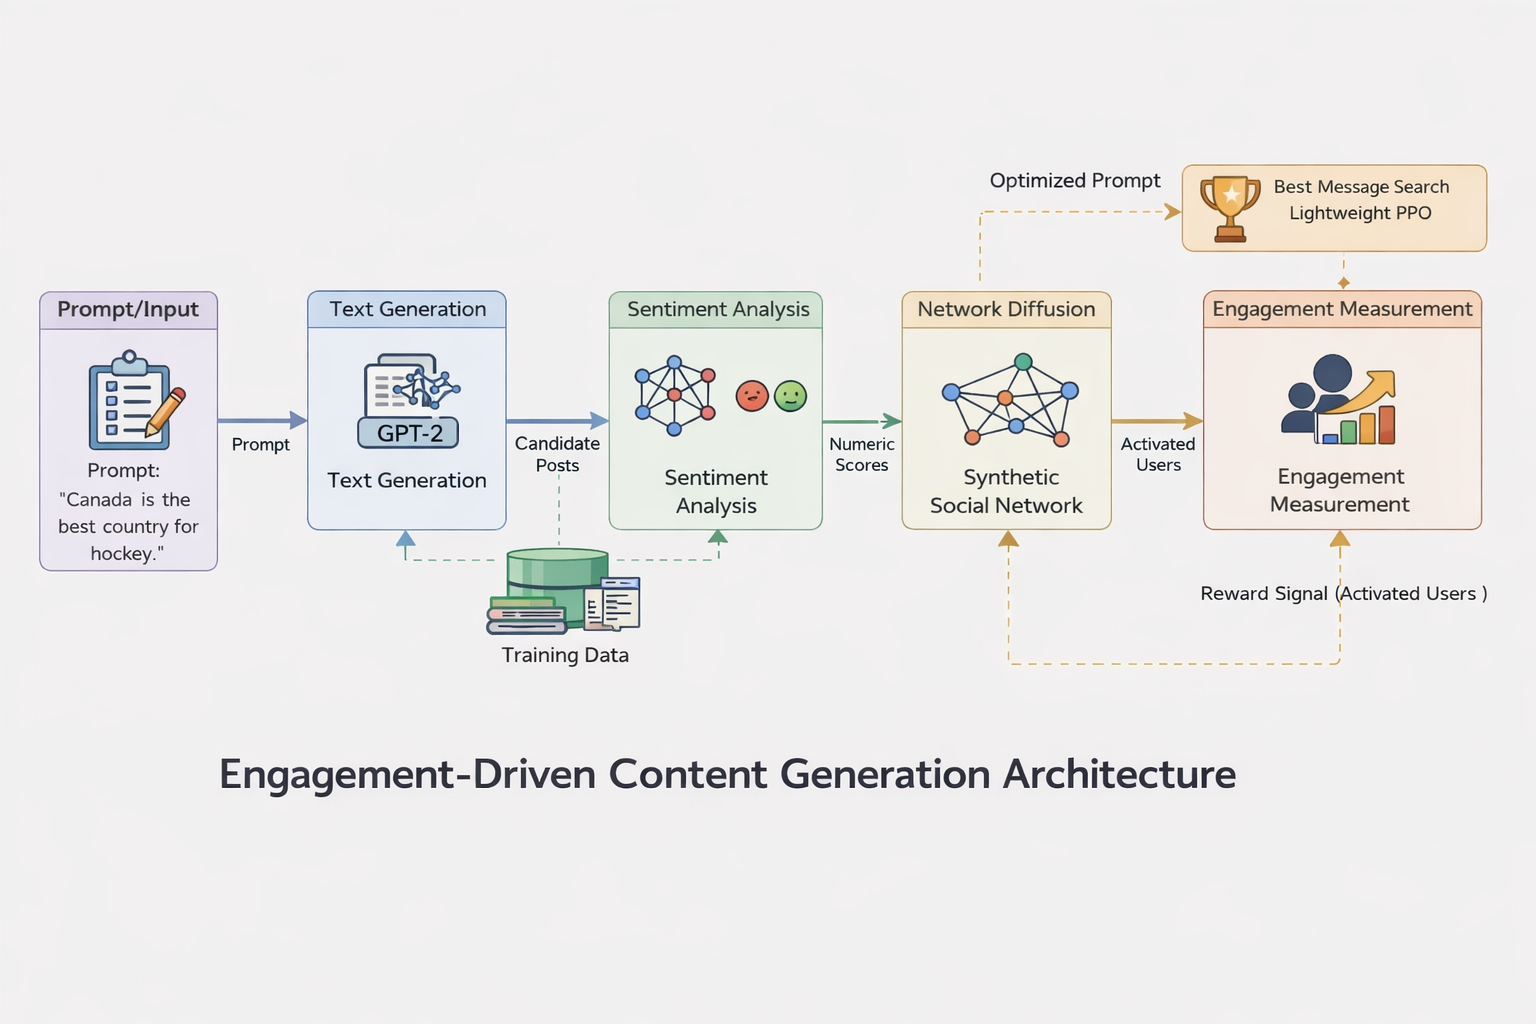

# Implementation

In this project, we implement a simplified engagement-driven content generation system that runs efficiently on a Mac without GPU support. The system includes four main components: social network generation, message generation, diffusion, and optimization.

A synthetic directed graph is created where each node represents a user with an opinion value between 0 and 1. Candidate posts are generated using a lightweight language model (gpt2) and converted into numerical values using sentiment analysis.

These message values are propagated through the network using a bounded-confidence diffusion model, where users are influenced only if the message aligns with their opinions. Engagement is measured by the number of activated users.

Finally, the system compares multiple messages, performs a search for the best message, and applies a lightweight PPO-style optimization to improve engagement. The graph is also visualized to illustrate how influence spreads across the network.

# 1: Import Libraries

In [1]:
# Import required libraries
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from transformers import pipeline
import random
import pandas as pd

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Create Synthetic Social Network

In [2]:
def create_graph(n=20, p=0.2, seed=42):
  """
  Create a synthetic directed social network with random user opinions.
  """
  #Set random seeds for reproducibility
  np.random.seed(seed)
  random.seed(seed)

  #generate random directed graph
  G = nx.erdos_renyi_graph(n, p, directed=True, seed=seed)
  #Create opinion values between 0 and 1
  opinions = np.random.rand(n)

  #Store each opinion as a node attribute
  for i in range(n):
    G.nodes[i]["opinion"] = float(opinions[i])

  return G, opinions

## 3: Diffusion Model

In [3]:
def propagate(G, opinions, message, start_node=0, threshold=0.3, alpha=0.5):
    """
    Simulate message diffusion through the network using a bounded-confidence rule.
    """
    #Copy opinions so orginal values are unchanged
    updated_opinions = opinions.copy()
    #Track visited nodes
    visited = set([start_node])
    #Queue for breadth-first diffusion
    queue = [start_node]
    #Store activated users
    activated_nodes = set([start_node])

    #Store activated users
    while queue:
        node = queue.pop(0)

        #Check neighbours of current node
        for neighbor in G.neighbors(node):

            #Only process unseen neighbours
            if neighbor not in visited:
                #Difference between user opinion and message
                diff = abs(updated_opinions[neighbor] - message)
                #User accepts the message if difference is small enough
                if diff < threshold:

                    #Move user opinion toward message
                    updated_opinions[neighbor] += alpha * (
                        message - updated_opinions[neighbor]
                    )

                    #Mark user as activated
                    activated_nodes.add(neighbor)
                    #Allow activated user to influence others
                    queue.append(neighbor)
                #Mark neighbour as visited
                visited.add(neighbor)

    return len(activated_nodes), updated_opinions, activated_nodes

## 4:Visualization Function

In [4]:
def plot_graph(G, opinions, activated_nodes=None, title="Graph"):
  """
  Visualize the social network with node opionions and activated nodes.
  """
  #Create figure
  plt.figure(figsize=(8, 6))
  #Compute graph layout
  pos = nx.spring_layout(G, seed=42)

  #Use opionions as node colours
  node_colors = opinions
  #Store node sizes
  node_sizes = []

  #Make activated nodes larger
  for node in G.nodes():
      if activated_nodes is not None and node in activated_nodes:
          node_sizes.append(700)
      else:
          node_sizes.append(350)

  #Draw graph
  nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=node_colors,
        node_size=node_sizes,
        cmap=plt.cm.coolwarm
    )

  plt.title(title)
  plt.show()

## 5. Message Generation & Sentiment

In [5]:
#Load GPT-2 text generation model
generator = pipeline("text-generation", model="gpt2")
#Load sentiment analysis model
sentiment_model = pipeline("sentiment-analysis")

def generate_post(prompt="Climate action is"):
  """
  Generate a text post from a given prompt using GPT-2.
  """

  #Generate text from prompt
  result = generator(
        prompt,
        max_length=400,
        num_return_sequences=1,
        truncation=True
    )
  return result[0]["generated_text"]

def get_sentiment_score(text):
  """
  Convert text sentiment into a numeric value between 0 and 1
  """
  #Run sentiment model
  result = sentiment_model(text)[0]

  #Extract label and confidence score
  label = result["label"]
  score = result["score"]

  #Positive text gets higher values
  if label.upper() == "POSITIVE":
      return float(score)
  #Negative text gets lower values
  else:
      return float(1 - score)

/usr/local/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


## 6. Multiple Message Comparison

In [6]:
def test_multiple_messages(G, opinions, prompts):
  """
  Generate posts from prompts, score sentiment, run diffusion
  and compare engagement resukts for each message.
  """
  #Store results for all prompts
  records = []

  #Test each prompt one by one
  for i, prompt in enumerate(prompts, start=1):
    #Generate text from prompt
    post = generate_post(prompt)
    #Convert generated test to numeric sentiment value
    sentiment_value = get_sentiment_score(post)

    #Run diffusion model using message value
    activated_count, updated_opinions, activated_nodes = propagate(
            G, opinions, sentiment_value, start_node=0
    )

    #Save results for this prompt
    records.append({
            "Post Number": i,
            "Prompt": prompt,
            "Post Text": post,
            "Sentiment Score": round(sentiment_value, 3),
            "Engagement Score": activated_count,
            "Activated Nodes": activated_nodes,
            "Updated Opinions": updated_opinions
      })

  return pd.DataFrame(records)

## 7. Best Message Search

In [7]:
def search_best_message(G, opinions, resolution=21):
  """
  Brute-force search over message values in [0, 1] to find
  the highest engagement in the diffusion model.
  """
  #Store the best result found so far
  best_score = -1
  best_message = None
  best_nodes = None
  best_updated = None

  #Test candidate emssage values from 0 to 1
  for val in np.linspace(0, 1, resolution):
      #Run diffusion model for current message value
      activated_count, updated_opinions, activated_nodes = propagate(
          G, opinions, message=val, start_node=0
      )

      #Update best result if engagement improves
      if activated_count > best_score:
            best_score = activated_count
            best_message = val
            best_nodes = activated_nodes
            best_updated = updated_opinions

  return best_message, best_score, best_nodes, best_updated

## 8. Lightweight PPO-style Optimization

In [15]:
def lightweight_ppo(G, opinions, iterations=8, candidates_per_iter=6, step_size=0.12):
    current_message = random.random()
    history = []

    for it in range(iterations):
        candidates = [current_message]

        for _ in range(candidates_per_iter - 1):
            proposal = current_message + np.random.uniform(-step_size, step_size)
            proposal = min(max(proposal, 0.0), 1.0)
            candidates.append(proposal)

        candidate_scores = []
        for c in candidates:
            activated_count, _, _ = propagate(G, opinions, c, start_node=0)
            candidate_scores.append((c, activated_count))

        best_candidate, best_score = max(candidate_scores, key=lambda x: x[1])
        current_message = best_candidate

        history.append({
            "Iteration": it + 1,
            "Best Message": round(current_message, 3),
            "Best Engagement": best_score
        })

    return current_message, pd.DataFrame(history)





## 8. Lightweight PPO-style Optimization (improved)





In [16]:
def lightweight_ppo_improved(
    G, opinions,
    resolution=21,
    iterations=10,
    batch_size=12,
    lr=0.35,
    clip_eps=0.2,
    kl_mix=0.1,
    seed=42
):
    rng = np.random.default_rng(seed)
    message_grid = np.linspace(0, 1, resolution)

    probs = np.ones(resolution, dtype=float)
    probs = probs / probs.sum()

    best_message = None
    best_score = -1
    best_nodes = None
    best_updated = None

    history = []

    def softmax(x):
        x = x - np.max(x)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x)

    for it in range(iterations):
        old_probs = probs.copy()
        old_probs = old_probs / old_probs.sum()

        sampled_idx = rng.choice(
            np.arange(resolution),
            size=batch_size,
            replace=True,
            p=old_probs
        )

        sampled_rewards = []

        for idx in sampled_idx:
            msg = float(message_grid[idx])

            activated_count, updated_opinions, activated_nodes = propagate(
                G, opinions, msg, start_node=0
            )

            sampled_rewards.append(activated_count)

            if activated_count > best_score:
                best_score = activated_count
                best_message = msg
                best_nodes = activated_nodes
                best_updated = updated_opinions

        sampled_rewards = np.array(sampled_rewards, dtype=float)

        baseline = sampled_rewards.mean()
        reward_std = sampled_rewards.std() + 1e-8
        advantages = (sampled_rewards - baseline) / reward_std

        action_adv = np.zeros(resolution, dtype=float)
        action_cnt = np.zeros(resolution, dtype=float)

        for idx, adv in zip(sampled_idx, advantages):
            action_adv[idx] += adv
            action_cnt[idx] += 1

        used = action_cnt > 0
        action_adv[used] = action_adv[used] / action_cnt[used]

        old_logits = np.log(old_probs + 1e-12)
        proposal_logits = old_logits + lr * action_adv
        proposal_probs = softmax(proposal_logits)

        ratios = proposal_probs / (old_probs + 1e-12)
        clipped_ratios = np.clip(ratios, 1 - clip_eps, 1 + clip_eps)

        clipped_probs = old_probs * clipped_ratios
        clipped_probs = clipped_probs / clipped_probs.sum()

        probs = (1 - kl_mix) * clipped_probs + kl_mix * old_probs
        probs = probs / probs.sum()

        current_idx = int(np.argmax(probs))
        current_message = float(message_grid[current_idx])

        history.append({
            "Iteration": it + 1,
            "Best Message": round(current_message, 3),
            "Best Probability": round(float(probs[current_idx]), 4),
            "Batch Mean Reward": round(float(baseline), 3),
            "Best Engagement So Far": int(best_score)
        })

    history_df = pd.DataFrame(history)

    return best_message, best_score, best_nodes, best_updated, history_df

## 9. Main Execution

Initial opinions:
[0.37 0.95 0.73 0.6  0.16 0.16 0.06 0.87 0.6  0.71 0.02 0.97 0.83 0.21
 0.18 0.18 0.3  0.52 0.43 0.29]


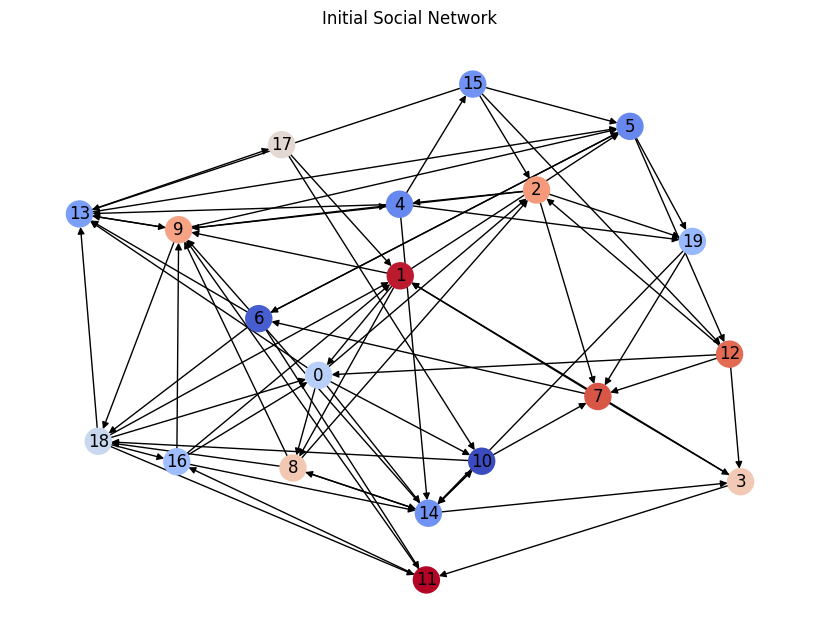

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Multiple Message Comparison:
                                           Post Text
0  IRAN WAR and Trump's war on drugs were, in fac...
1  Climate action is crucial to creating the envi...
2  The future of clean energy is not assured this...
3  Our community should support a constitutional ...
4  Public policy must prioritize its use for loca...
                                           Post Text  Post Number  \
0  IRAN WAR and Trump's war on drugs were, in fac...            1   
1  Climate action is crucial to creating the envi...            2   
2  The future of clean energy is not assured this...            3   
3  Our community should support a constitutional ...            4   
4  Public policy must prioritize its use for loca...            5   

                          Prompt  Sentiment Score  Engagement Score  
0             IRAN WAR and Trump            0.018                 7  
1              Climate action is            0.993                 5  
2  The future of clean ener

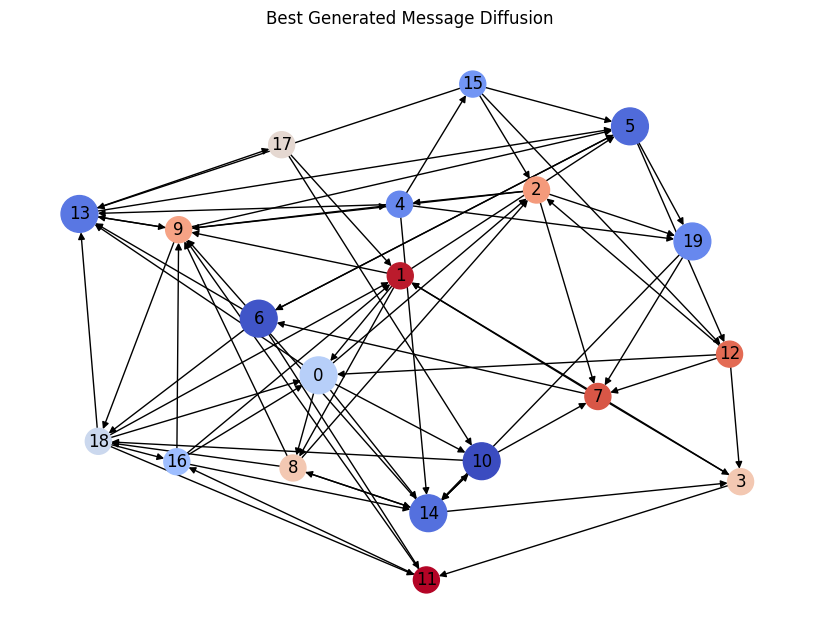


Best Message Value: 0.45
Best Engagement: 14



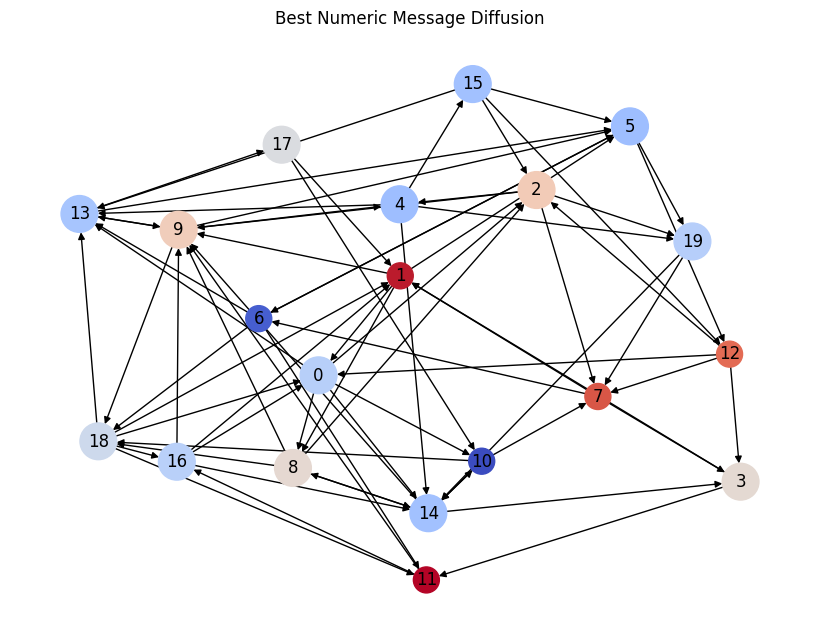


PPO Optimization History:
   Iteration  Best Message  Best Engagement
0          1         0.590                9
1          2         0.481               11
2          3         0.481               11
3          4         0.434               14
4          5         0.434               14
5          6         0.434               14
6          7         0.434               14
7          8         0.434               14


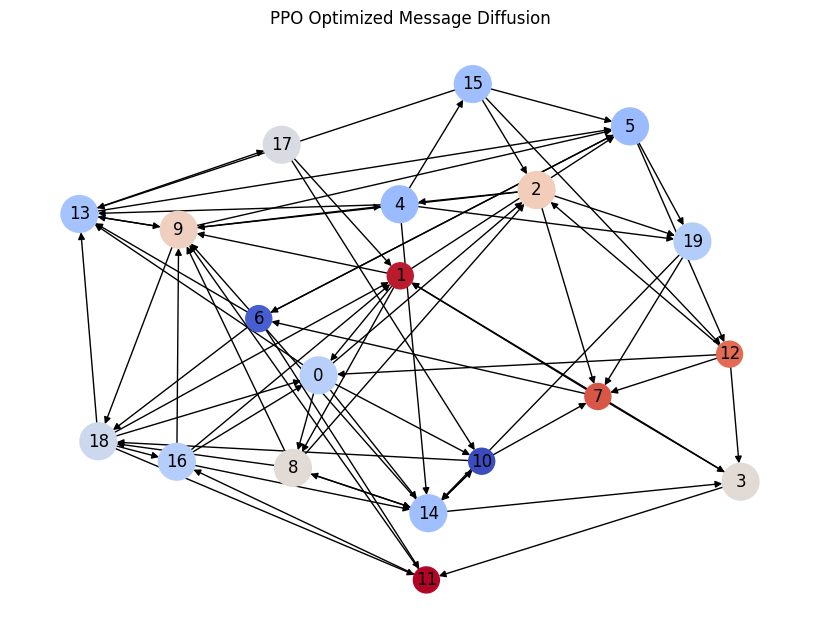

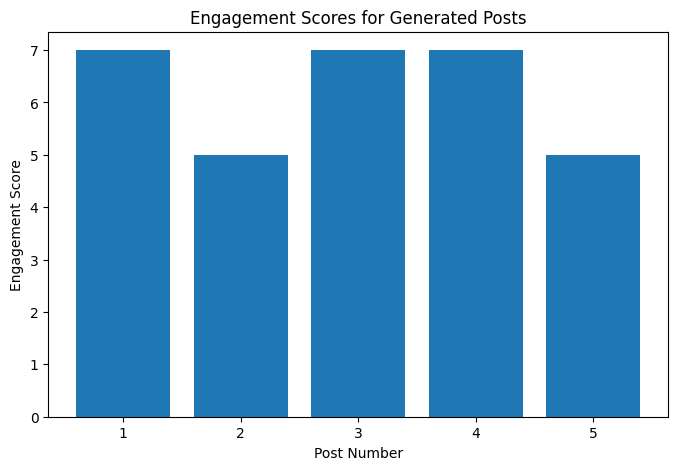


Improved PPO-style Optimization History:
   Iteration  Best Message  Best Probability  Batch Mean Reward  \
0          1          0.35            0.0576              8.500   
1          2          0.35            0.0720              8.167   
2          3          0.45            0.0869              9.417   
3          4          0.45            0.1075              9.583   
4          5          0.45            0.1400              8.917   
5          6          0.45            0.1695             10.750   
6          7          0.45            0.2171              9.333   
7          8          0.45            0.2633             10.417   
8          9          0.45            0.3271              8.833   
9         10          0.45            0.3911             11.250   

   Best Engagement So Far  
0                      14  
1                      14  
2                      14  
3                      14  
4                      14  
5                      14  
6                      1

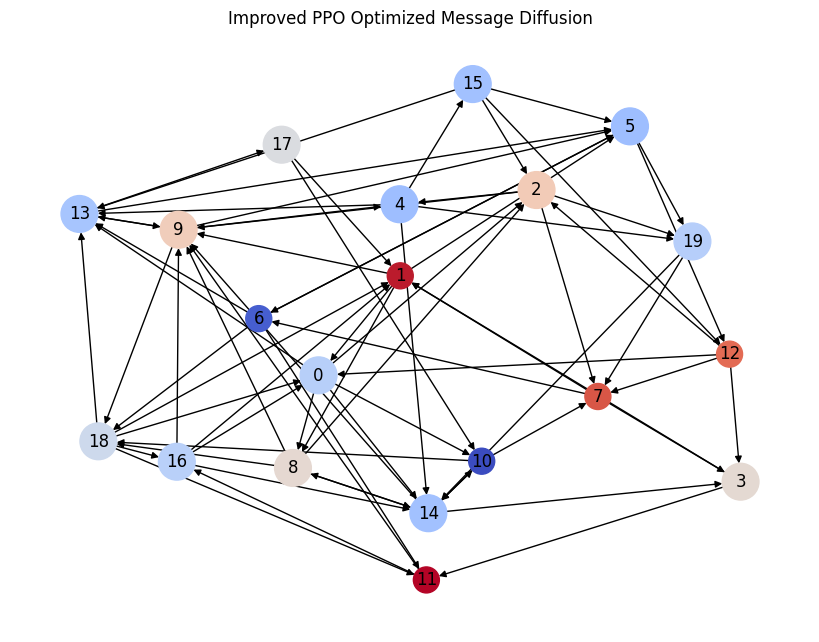

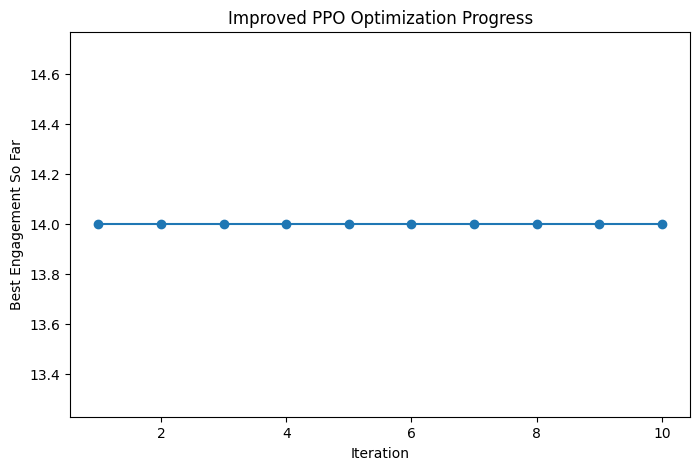

In [ ]:
G, opinions = create_graph(n=20, p=0.2, seed=42)

print("Initial opinions:")
print(np.round(opinions, 2))

plot_graph(G, opinions, title="Initial Social Network")

prompts = [
    "IRAN WAR and Trump",
    "Climate action is",
    "The future of clean energy is",
    "Our community should support",
    "Public policy must prioritize"
]

results_df = test_multiple_messages(G, opinions, prompts)

print("\nMultiple Message Comparison:")
print(results_df[["Post Text"]])
print(results_df[["Post Text","Post Number", "Prompt", "Sentiment Score", "Engagement Score"]])

best_post_row = results_df.sort_values("Engagement Score", ascending=False).iloc[0]

plot_graph(
    G,
    best_post_row["Updated Opinions"],
    activated_nodes=best_post_row["Activated Nodes"],
    title="Best Generated Message Diffusion"
)

best_value, best_score, best_nodes, best_updated = search_best_message(G, opinions)

print("\nBest Message Value:", round(best_value, 3))
print("Best Engagement:", best_score)

print()

plot_graph(
    G,
    best_updated,
    activated_nodes=best_nodes,
    title="Best Numeric Message Diffusion"
)

ppo_message, ppo_history = lightweight_ppo(G, opinions)

print("\nPPO Optimization History:")
print(ppo_history)

ppo_score, ppo_updated, ppo_nodes = propagate(G, opinions, ppo_message)

plot_graph(
    G,
    ppo_updated,
    activated_nodes=ppo_nodes,
    title="PPO Optimized Message Diffusion"
)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Post Number"].astype(str), results_df["Engagement Score"])
plt.xlabel("Post Number")
plt.ylabel("Engagement Score")
plt.title("Engagement Scores for Generated Posts")
plt.show()


#Improved PPO
ppo2_message, ppo2_score, ppo2_nodes, ppo2_updated, ppo2_history = lightweight_ppo_improved(
    G, opinions,
    resolution=21,
    iterations=10,
    batch_size=12,
    lr=0.35,
    clip_eps=0.2,
    kl_mix=0.1,
    seed=42
)

print("\nImproved PPO-style Optimization History:")
print(ppo2_history)

print("\nBest Improved PPO Message Value:", round(ppo2_message, 3))
print("Best Improved PPO Engagement:", ppo2_score)

plot_graph(
    G,
    ppo2_updated,
    activated_nodes=ppo2_nodes,
    title="Improved PPO Optimized Message Diffusion"
)



![Comparison: Original Paper vs Our Project](comparison_original_vs_our_project.png)

*Comparison: Original Paper vs Our Project*

# Conclusion and Future Direction

In this project, we implemented a simplified engagement-driven content generation system using a synthetic social network and diffusion model. The results and graph visualization show that content effectiveness depends on how well the message aligns with user opinions and network structure. Messages closer to the overall opinion distribution activate more users and achieve higher engagement.

The main strength of this approach is that it captures network-aware content optimization in a computationally efficient way. However, the model has limitations, including the use of synthetic data, simplified sentiment scoring, and a lightweight approximation of reinforcement learning.

In future work, this system can be improved by using real-world datasets, more advanced language models, and full reinforcement learning methods. Additional enhancements could include modeling dynamic user behavior and more realistic engagement metrics.

# References:

[1]: Erica Coppolillo, Federico Cinus, Marco Minici, Francesco Bonchi, and Giuseppe Manco, Engagement-Driven Content Generation with Large Language Models, Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining (KDD), 2025.

